## Estudio del dengue/chikungunya en México 01/01/2024 hasta 02/09/2024 ##

El **dengue** (al igual que la **chikungunya**) es una enfermedad causada por un virus y se transmite a las personas por la picadura del mosquito portador de la 
enfermedad.

<div> <img src="foto_dengue.png" alt="Drawing" style="width: 250px;"/></div>

Al presentarse principalmente en regiones tropicales y subtropicales, es importante analizar esta enfermedad en México.

El **objetivo principal** de este proyecto es poder determinar, dadas las variables, si el paciente fallecerá.

Entre los **objetivos** secundarios se encuentran:

- Determinar el impacto de otras enfermedades con el virus.
- Determinar zonas de mayor riesgo de transmisión del virus.
- Estudiar la relación del sexo del paciente con el virus.

La base de datos fue obtenida los  Datos Abiertos Dirección General de Epidemiología del gobierno federal de México (https://www.gob.mx/salud/documentos/datos-abiertos-152127), aunque es importante recalcar que esta base se actualiza semanalmente, por lo que para tratar de reproducir exactamente este trabajo será necesario consultar https://github.com/EduardoTF/Ciencia-de-Datos-UAS


## Lectura y prsentación de los datos ##

In [1]:
#Base de datos dengue/chikunguya México (01/01/2024 - 02/09/2024) y cátalogos descriptivos

#------------------------------------------------------------------------------
#Librerías

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from fitter import Fitter
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

#------------------------------------------------------------------------------
#Base de datos y catálogos

dengue_data = pd.read_csv("dengue_abierto.csv")    #Base de datos

#------------------------------------------------------------------------------

#Catálogos
dengue_descr = pd.read_csv("Descriptores_Dengue.csv")
dengue_caso = pd.read_csv("CATALOGO_ESTATUS_CASO.csv")
dengue_PCR = pd.read_csv("CATALOGO_RESULTADO_PCR.csv")
dengue_dict = pd.read_csv("CATALOGO_DICTAMEN.csv")
dengue_tpx = pd.read_csv("CATALOGO_TIPO_PACIENTE.csv")
dengue_munic = pd.read_csv("CATALOGO_MUNICIPIOS.csv")
dengue_entidad = pd.read_csv("CATALOGO_ENTIDAD.csv")
dengue_inst = pd.read_csv("CATALOGO_INSTITUCION.csv")
dengue_si_no = pd.read_csv("CATALOGO_SI_NO.csv")
dengue_sexo = pd.read_csv("CATALOGO_SEXO.csv")

In [2]:
#Base de datos dengue/chikunguya México (01/01/2024 - 02/09/2024)

dengue_data

,FECHA_ACTUALIZACION,ID_REGISTRO,SEXO,EDAD_ANOS,ENTIDAD_RES,MUNICIPIO_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,...,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG,MUNICIPIO_ASIG
0,02/09/2024,849113,2,35,12,29,2,2,12,29,...,2,2,2,2,5.0,1,5,3,12,29
1,02/09/2024,873810,2,55,18,17,2,2,18,17,...,2,2,2,2,5.0,2,5,1,18,17
2,02/09/2024,1081911,2,11,20,67,2,2,20,67,...,2,2,2,2,5.0,2,5,1,20,67
3,02/09/2024,1207499,1,51,17,11,2,2,17,11,...,2,2,2,2,5.0,1,5,1,17,11
4,02/09/2024,1299508,1,5,23,5,2,2,23,5,...,2,2,2,2,5.0,1,5,3,23,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,02/09/2024,1564857,2,34,17,18,2,2,17,7,...,2,2,2,2,5.0,1,5,1,17,18
237592,02/09/2024,1564858,1,21,17,7,2,2,17,7,...,2,2,2,2,5.0,1,5,1,17,7
237593,02/09/2024,1564859,2,3,7,40,2,2,7,40,...,2,2,2,2,5.0,1,5,1,7,40
237594,02/09/2024,1564860,1,19,15,82,2,2,15,82,...,2,2,2,2,5.0,1,5,1,15,82


<div class="alert alert-block alert-info">
<b>

La base de de datos cuenta con 28 variables y 237,596 pacientes registrados.

In [3]:
#Tipos de datos de la base de datos

print(dengue_data.dtypes)


FECHA_ACTUALIZACION        object
ID_REGISTRO                 int64
SEXO                        int64
EDAD_ANOS                   int64
ENTIDAD_RES                 int64
MUNICIPIO_RES               int64
HABLA_LENGUA_INDIG          int64
INDIGENA                    int64
ENTIDAD_UM_NOTIF            int64
MUNICIPIO_UM_NOTIF          int64
INSTITUCION_UM_NOTIF        int64
FECHA_SIGN_SINTOMAS        object
TIPO_PACIENTE               int64
HEMORRAGICOS                int64
DIABETES                    int64
HIPERTENSION                int64
ENFERMEDAD_ULC_PEPTICA      int64
ENFERMEDAD_RENAL            int64
INMUNOSUPR                  int64
CIRROSIS_HEPATICA           int64
EMBARAZO                    int64
DEFUNCION                   int64
DICTAMEN                  float64
TOMA_MUESTRA                int64
RESULTADO_PCR               int64
ESTATUS_CASO                int64
ENTIDAD_ASIG                int64
MUNICIPIO_ASIG              int64
dtype: object


In [4]:
#Descripción de los datos

dengue_data.describe()

,ID_REGISTRO,SEXO,EDAD_ANOS,ENTIDAD_RES,MUNICIPIO_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,INSTITUCION_UM_NOTIF,...,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG,MUNICIPIO_ASIG
count,2.375960e+05,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,...,237596.000000,237596.000000,237596.000000,237596.000000,237591.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000
mean,1.432164e+06,1.454566,28.883024,17.133083,56.398252,1.981485,1.977428,17.123929,52.729381,10.418113,...,1.998721,1.999263,1.987218,1.996444,4.994406,1.494516,4.800178,1.616454,17.417650,59.481035
std,7.599311e+04,0.497932,18.498862,7.098741,85.673926,0.134803,0.148535,7.099216,88.380208,7.908899,...,0.035747,0.027129,0.112334,0.059530,0.115136,0.499971,0.650382,0.807822,8.462982,100.929270
min,8.491130e+05,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.367372e+06,1.000000,14.000000,12.000000,8.000000,2.000000,2.000000,12.000000,7.000000,4.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,1.000000,5.000000,1.000000,12.000000,8.000000
50%,1.431172e+06,1.000000,26.000000,17.000000,29.000000,2.000000,2.000000,17.000000,31.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,1.000000,5.000000,1.000000,17.000000,29.000000
75%,1.495044e+06,2.000000,41.000000,21.000000,67.000000,2.000000,2.000000,21.000000,67.000000,20.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,5.000000,2.000000,21.000000,67.000000
max,1.564861e+06,2.000000,140.000000,35.000000,570.000000,2.000000,2.000000,32.000000,999.000000,99.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,5.000000,3.000000,99.000000,999.000000


In [5]:
#Busqueda de datos nulos y reemplazo de los mismos
print(dengue_data.isna().sum())
for col in ['DICTAMEN']:
    dengue_data[col]= dengue_data[col].fillna(5)
print()
print()
print()
print(dengue_data.isna().sum())

FECHA_ACTUALIZACION       0
ID_REGISTRO               0
SEXO                      0
EDAD_ANOS                 0
ENTIDAD_RES               0
MUNICIPIO_RES             0
HABLA_LENGUA_INDIG        0
INDIGENA                  0
ENTIDAD_UM_NOTIF          0
MUNICIPIO_UM_NOTIF        0
INSTITUCION_UM_NOTIF      0
FECHA_SIGN_SINTOMAS       0
TIPO_PACIENTE             0
HEMORRAGICOS              0
DIABETES                  0
HIPERTENSION              0
ENFERMEDAD_ULC_PEPTICA    0
ENFERMEDAD_RENAL          0
INMUNOSUPR                0
CIRROSIS_HEPATICA         0
EMBARAZO                  0
DEFUNCION                 0
DICTAMEN                  5
TOMA_MUESTRA              0
RESULTADO_PCR             0
ESTATUS_CASO              0
ENTIDAD_ASIG              0
MUNICIPIO_ASIG            0
dtype: int64



FECHA_ACTUALIZACION       0
ID_REGISTRO               0
SEXO                      0
EDAD_ANOS                 0
ENTIDAD_RES               0
MUNICIPIO_RES             0
HABLA_LENGUA_INDIG        0
INDI

In [6]:
#Catálogos descriptivos de la base de datos
print("Descriptores")
dengue_descr = pd.read_csv("Descriptores_Dengue.csv")
dengue_descr


Descriptores


,NO.,NOMBRE DE VARIABLE,DESCRIPCION,FORMATO O FUENTE
0,1,FECHA_ACTUALIZACION,LA BASE DE DATOS SE ACTUALIZA SEMANALMENTE. ES...,"AAAA-MM-DD, 9999-99-99: CUANDO NO HAY REGISTRO"
1,2,ID_REGISTRO,NÚMERO DE INDETIFICADOR DEL CASO,TEXTO
2,3,SEXO,IDENTIFICA EL SEXO DEL PACIENTE,CATÁLOGO: SEXO
3,4,EDAD_ANOS,IDENTIFICA LA EDAD EN AÑOS DEL PACIENTE,NÚMERICA EN AÑOS
4,5,ENTIDAD_RES,IDENTIFICA LA ENTIDAD DE RESIDENCIA DEL PACIENTE,CATÁLOGO: ENTIDADES
5,6,MUNICIPIO_RES,IDENTIFICA EL MUNICIPIO DE RESIDENCIA DEL PACI...,CATÁLOGO: MUNICIPIOS
6,7,HABLA_LENGUA_INDIG,IDENTIFICA SI EL PACIENTE HABLA LENGUA INDIGENA,CATÁLOGO: SI /NO
7,8,INDIGENA,IDENTIFICA SI EL PACIENTE SE AUTOIDENTIFICA CO...,CATÁLOGO: SI /NO
8,9,ENTIDAD_UM_NOTIF,IDENTIFICA LA ENTIDAD DONDE SE ENCUENTRA LA UN...,CATÁLOGO: ENTIDADES
9,10,MUNICIPIO_UM_NOTIF,IDENTIFICA EL MUNICIPIO DONDE SE ENCUENTRA LA ...,CATÁLOGO: MUNICIPIOS


La mayoría de las variables están presentadas de forma categórica, por lo que es importante consultar de su catálogo correspondiente (si le es más facil, se puede descargar el catálogo en csv desde el GitHub del proyecto). De todas las variables, la única que presenta datos continuos es la edad. 

Los catálogos de la base de datos son los siguientes:

In [7]:
print("Estatus del caso")

dengue_caso


Estatus del caso


,CLAVE,DESCRIPCIÓN
0,1,PROBABLE
1,2,CONFIRMADO
2,3,DESCARTADO


In [8]:
print("Resultado del estudio PCR")

dengue_PCR


Resultado del estudio PCR


,CLAVE,DESCRIPCIÓN
0,1,DENV1
1,2,DENV2
2,3,DENV3
3,4,DENV4
4,5,SIN SEROTIPO AISLADO


Como en muchos virus, existen varias cepas o serotipos de dengue. En específico, existen 4 serotipos de dengue y se denominan DENV1, DENV2, DENV3 y DENV4.

<div> <img src="E8cqLkVWYAUVNla.jpg" alt="Drawing" style="width: 500px;"/></div>

In [9]:
print("Dictamen del paciente")

dengue_dict


Dictamen del paciente


,CLAVE,DESCRIPCIÓN
0,1,CONFIRMADO A DENGUE
1,2,CONFIRMADO A CHIKUNGUNYA
2,3,NEGATIVO
3,4,EN ESTUDIO
4,5,NO APLICA


In [10]:
print("Tipo de tratamiento del paciente")

dengue_tpx


Tipo de tratamiento del paciente


,CLAVE,DESCRIPCIÓN
0,1,AMBULATORIO
1,2,HOSPITALIZADO


In [11]:
print("Municipios")

dengue_munic


Municipios


,CLAVE_MUNICIPIO,MUNICIPIO,CLAVE_ENTIDAD
0,1,AGUASCALIENTES,01
1,2,ASIENTOS,01
2,3,CALVILLO,01
3,4,COSÍO,01
4,5,JESÚS MARÍA,01
...,...,...,...
2498,335,OTROS PAISES,OTROS
2499,999,NO ESPECIFICADO,32
2500,997,NO APLICA,97
2501,998,SE IGNORA,98


In [12]:
print("Entidades")

dengue_entidad


Entidades


,CLAVE_ENTIDAD,ENTIDAD_FEDERATIVA,ABREVIATURA
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [13]:
print("Catalogación del si y no")

dengue_si_no


Catalogación del si y no


,CLAVE,DESCRIPCIÓN
0,1,SI
1,2,NO


In [14]:
print("Sexo del paciente")

dengue_sexo

Sexo del paciente


,CLAVE,DESCRIPCIÓN
0,1,MUJER
1,2,HOMBRE


In [15]:
print("Institucion de atención del paciente")

dengue_inst 

Institucion de atención del paciente


,CLAVE,DESCRIPCIÓN
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


<div class="alert alert-block alert-info">
<b>

Se puede concluir que la base de datos ofrecida por el gobierno de México se encuentra con una organización y limpieza de los datos excelente. Esta base de datos apenas presenta 5 valores nulos y cada variable se encuentra categorizada de manera sencilla e inequívoca.

## Primera eliminación de variables ##

Para los objetivos de este proyecto, en primeras instancias hay variables que no nos son de utilidad, ya sea porque suelen servir para identificar al paciente, indicar la fecha o el municipio. 

In [16]:
#Primera eliminación de variables

print('Primera eliminación de variables')
dengue_data.drop(columns=['FECHA_ACTUALIZACION','ID_REGISTRO','MUNICIPIO_RES','MUNICIPIO_UM_NOTIF','MUNICIPIO_ASIG', "FECHA_SIGN_SINTOMAS"],inplace=True) 

dengue_data

Primera eliminación de variables


,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
0,2,35,12,2,2,12,12,1,2,2,...,2,2,2,2,2,5.0,1,5,3,12
1,2,55,18,2,2,18,4,1,2,2,...,2,2,2,2,2,5.0,2,5,1,18
2,2,11,20,2,2,20,20,1,2,2,...,2,2,2,2,2,5.0,2,5,1,20
3,1,51,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
4,1,5,23,2,2,23,4,1,2,2,...,2,2,2,2,2,5.0,1,5,3,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,2,34,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237592,1,21,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237593,2,3,7,2,2,7,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,7
237594,1,19,15,2,2,15,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,15


También es importante descartar los pacientes registrados confirmados negativos a dengue o chikungunya

In [17]:
#Eliminación de datos con pacientes negativos

dengue_data.drop(dengue_data.loc[dengue_data['ESTATUS_CASO'] == 3].index,inplace=True)

dengue_data


,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
1,2,55,18,2,2,18,4,1,2,2,...,2,2,2,2,2,5.0,2,5,1,18
2,2,11,20,2,2,20,20,1,2,2,...,2,2,2,2,2,5.0,2,5,1,20
3,1,51,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
5,2,3,27,2,2,27,20,1,2,2,...,2,2,2,2,2,5.0,2,5,1,27
6,1,23,20,2,2,20,4,1,2,2,...,2,2,2,2,2,5.0,2,5,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,2,34,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237592,1,21,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237593,2,3,7,2,2,7,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,7
237594,1,19,15,2,2,15,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,15


## Exploración de los datos ##

Primero separamos a los pacientes entre los que fallecieron y los que se recuperaron.

In [18]:
#Defunciones por dengue

defun_data = dengue_data[(dengue_data['DEFUNCION'] == 1)]


print(defun_data)

defun_data.describe()


        SEXO  EDAD_ANOS  ENTIDAD_RES  HABLA_LENGUA_INDIG  INDIGENA  \
250        1         32           15                   2         2   
494        2         42           23                   2         2   
570        1         14           12                   2         2   
2268       1         25            4                   2         2   
2861       2         10           12                   2         2   
...      ...        ...          ...                 ...       ...   
229914     1         28           12                   2         2   
230671     2         62           25                   2         2   
230860     2         62           25                   2         2   
232202     1         79           12                   2         2   
234979     2         26           12                   1         1   

        ENTIDAD_UM_NOTIF  INSTITUCION_UM_NOTIF  TIPO_PACIENTE  HEMORRAGICOS  \
250                   15                     6              2             2   
4

,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,...,404.000000,404.000000,404.000000,404.000000,404.0,404.000000,404.000000,404.00000,404.000000,404.000000
mean,1.435644,37.329208,16.750000,1.982673,1.975248,16.801980,12.537129,1.957921,1.950495,1.863861,...,1.970297,1.990099,1.995050,1.962871,1.0,3.064356,1.163366,4.29703,1.700495,17.591584
std,0.496456,25.066127,6.855066,0.130647,0.155562,6.887641,11.076370,0.201019,0.217189,0.343361,...,0.169977,0.099133,0.070272,0.189312,0.0,1.472938,0.370158,1.02857,0.458609,10.604977
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.00000,1.000000,3.000000
25%,1.000000,14.000000,12.000000,2.000000,2.000000,12.000000,4.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,1.000000,1.000000,3.00000,1.000000,12.000000
50%,1.000000,32.500000,17.000000,2.000000,2.000000,17.000000,12.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,4.000000,1.000000,5.00000,2.000000,17.000000
75%,2.000000,59.000000,20.000000,2.000000,2.000000,20.000000,20.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,4.000000,1.000000,5.00000,2.000000,20.000000
max,2.000000,92.000000,32.000000,2.000000,2.000000,31.000000,99.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,5.000000,2.000000,5.00000,2.000000,99.000000


In [19]:
#Recuperados por dengue

recup_data = dengue_data[(dengue_data['DEFUNCION'] == 2)]


print(recup_data)

recup_data.describe()


        SEXO  EDAD_ANOS  ENTIDAD_RES  HABLA_LENGUA_INDIG  INDIGENA  \
1          2         55           18                   2         2   
2          2         11           20                   2         2   
3          1         51           17                   2         2   
5          2          3           27                   2         2   
6          1         23           20                   2         2   
...      ...        ...          ...                 ...       ...   
237591     2         34           17                   2         2   
237592     1         21           17                   2         2   
237593     2          3            7                   2         2   
237594     1         19           15                   2         2   
237595     1         40           15                   2         2   

        ENTIDAD_UM_NOTIF  INSTITUCION_UM_NOTIF  TIPO_PACIENTE  HEMORRAGICOS  \
1                     18                     4              1             2   
2

,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
count,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,...,187756.000000,187756.000000,187756.000000,187756.000000,187756.0,187756.0,187756.000000,187756.000000,187756.000000,187756.000000
mean,1.459937,28.505710,16.920759,1.981801,1.978035,16.911587,10.285472,1.161124,1.993236,1.978962,...,1.998503,1.999158,1.999537,1.989806,2.0,5.0,1.625115,4.748775,1.251987,17.099283
std,0.498394,18.218697,6.919257,0.133671,0.146569,6.918182,8.084422,0.367646,0.081966,0.143511,...,0.038657,0.028997,0.021521,0.100450,0.0,0.0,0.484095,0.720439,0.434155,7.835208
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,2.0,5.0,1.000000,1.000000,1.000000,1.000000
25%,1.000000,14.000000,12.000000,2.000000,2.000000,12.000000,4.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,1.000000,5.000000,1.000000,12.000000
50%,1.000000,26.000000,17.000000,2.000000,2.000000,17.000000,5.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,2.000000,5.000000,1.000000,17.000000
75%,2.000000,40.000000,20.000000,2.000000,2.000000,20.000000,20.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,2.000000,5.000000,2.000000,20.000000
max,2.000000,140.000000,35.000000,2.000000,2.000000,32.000000,99.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,2.000000,5.000000,2.000000,99.000000


Visualizando los datos de recuperación y defunción por sexo:

<Figure size 200x200 with 0 Axes>

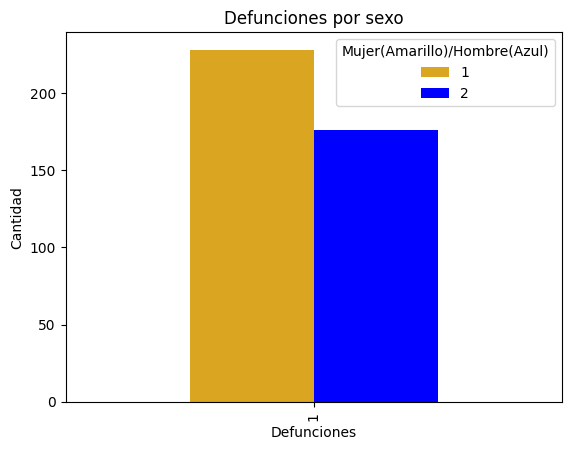

<Figure size 200x200 with 0 Axes>

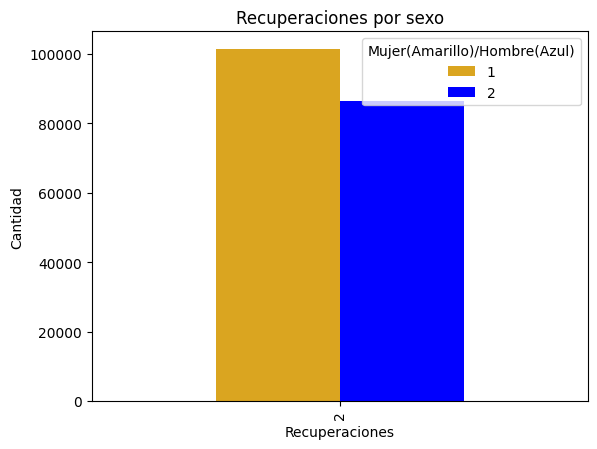

In [20]:
#Separamos los datos a graficar

desired_columns = ['SEXO','DEFUNCION','EDAD_ANOS']

SubData1 = dengue_data[desired_columns] #Obtener Sexo, Defunción y Edad

Defun = SubData1[SubData1['DEFUNCION']==1] #Difuntos
Recup = SubData1[SubData1['DEFUNCION']==2] #Recuperados

#-------------------------------------------------------------------------------------------

#Gráfica de barras de defunciones por sexo
defun_recup = Defun.groupby('DEFUNCION')['SEXO'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
defun_recup.plot(kind='bar',stacked=False, color=['goldenrod','blue'])
plt.xlabel('Defunciones')
plt.ylabel('Cantidad')
plt.title('Defunciones por sexo')
plt.legend(title='Mujer(Amarillo)/Hombre(Azul)')
plt.show()

#-------------------------------------------------------------------------------------------

#Gráfica de barras de defunciones por sexo
defun_recup = Recup.groupby('DEFUNCION')['SEXO'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
defun_recup.plot(kind='bar',stacked=False, color=['goldenrod','blue'])
plt.xlabel('Recuperaciones')
plt.ylabel('Cantidad')
plt.title('Recuperaciones por sexo')
plt.legend(title='Mujer(Amarillo)/Hombre(Azul)')
plt.show()

In [39]:
Mujer = dengue_data[dengue_data["SEXO"]==1]
Hombre = dengue_data[dengue_data["SEXO"]==2]

porc_mujer = (len(Mujer)/len(dengue_data))*100
porc_hombre = (len(Hombre)/len(dengue_data))*100

print("Tenemos que el porcentaje de mujeres en los contagiados por dengue/chikungunya es de %.2f" %(porc_mujer),"%,")
print("mientras que el porcentaje de hombres es de %.2f" %(porc_hombre), "%.")


Tenemos que el porcentaje de mujeres en los contagiados por dengue/chikungunya es de 54.01 %,
mientras que el porcentaje de hombres es de 45.99 %.


<div class="alert alert-block alert-info">
<b>

Tenemos que en general se encuentran muchas más personas que se recuperaron del dengue/chikungunya que aquellas que lamentablemente fallecieron. Por esto es que se separan las gráficas de barras entre los pacientes recuperados y los difuntos.

Es importante no infravalorar la letalidad del dengue/chikungunya, pues estos datos pueden estar sesgados por el sesgo del superviviente, puesto que estos datos están hecho para las personas que fueron atendidas en una unidad médica y no cubre aquellas que no buscaron o no tuvieron acceso a atención médica.

También se puede concluir que hay una ligera tendencia a que las mujeres se contagien más que los hombres, aunque se encuentran casi en el mismo porcentaje (54.01 % y 45.99 %, respectivamente.), por lo que es posible que esta no sea una variable determinante para nuestro modelo.

<Figure size 200x200 with 0 Axes>

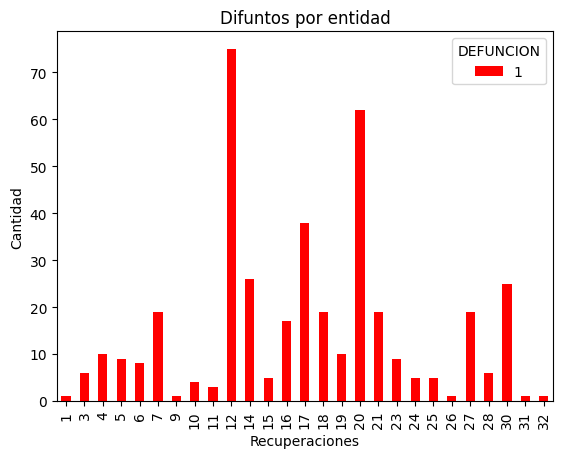

<Figure size 200x200 with 0 Axes>

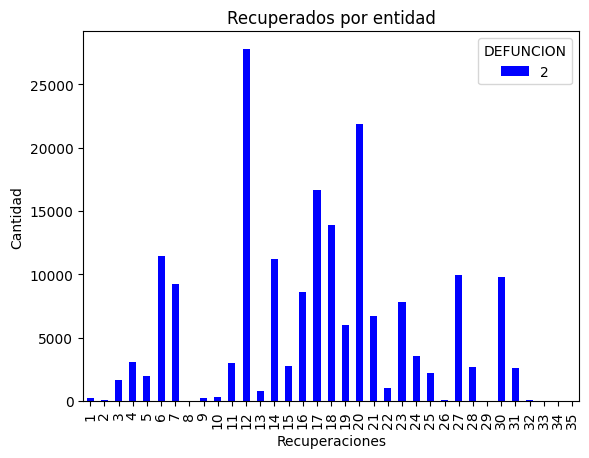

In [22]:
#Separamos los datos para los estados de la república

desired_columns = ['ENTIDAD_RES','DEFUNCION']

SubData2 = dengue_data[desired_columns] #Obtener Entidad y defunción

Defun = SubData2[SubData2['DEFUNCION']==1] #Difuntos
Recup = SubData2[SubData2['DEFUNCION']==2] #Recuperados

#-------------------------------------------------------------------------------------------
#Gráfica de barras de defunciones por estado
defun_est = Defun.groupby('ENTIDAD_RES')['DEFUNCION'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
defun_est.plot(kind='bar',stacked=False, color = "red")
plt.xlabel('Recuperaciones')
plt.ylabel('Cantidad')
plt.title('Difuntos por entidad')
plt.show()

#-------------------------------------------------------------------------------------------
#Gráfica de barras de recuperados por estado
recup_est = Recup.groupby('ENTIDAD_RES')['DEFUNCION'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
recup_est.plot(kind='bar',stacked=False, color = "blue")
plt.xlabel('Recuperaciones')
plt.ylabel('Cantidad')
plt.title('Recuperados por entidad')
plt.show()


<div class="alert alert-block alert-info">
<b>

Las entidades de la república mexicana que más casos tienen de dengue/chikungunya (tanto recuperados como difuntos) son <ins>Guerrero</ins> (12), <ins>Oaxaca</ins> (20) y <ins>Morelos</ins> (17).

## Segunda eliminación de variables ##

Ahora se mostrarán las correlaciones entre las variables de la base de datos del dengue/chikungunya:

In [23]:
def corr_matrix(data): #matriz de correlación
    correlation = data.corr()
    plt.figure(figsize=(20, 12))
    sns.heatmap(correlation, annot=True, fmt='.3f', cbar=True, cmap="RdYlGn")

La matriz de correlación para la defunción es


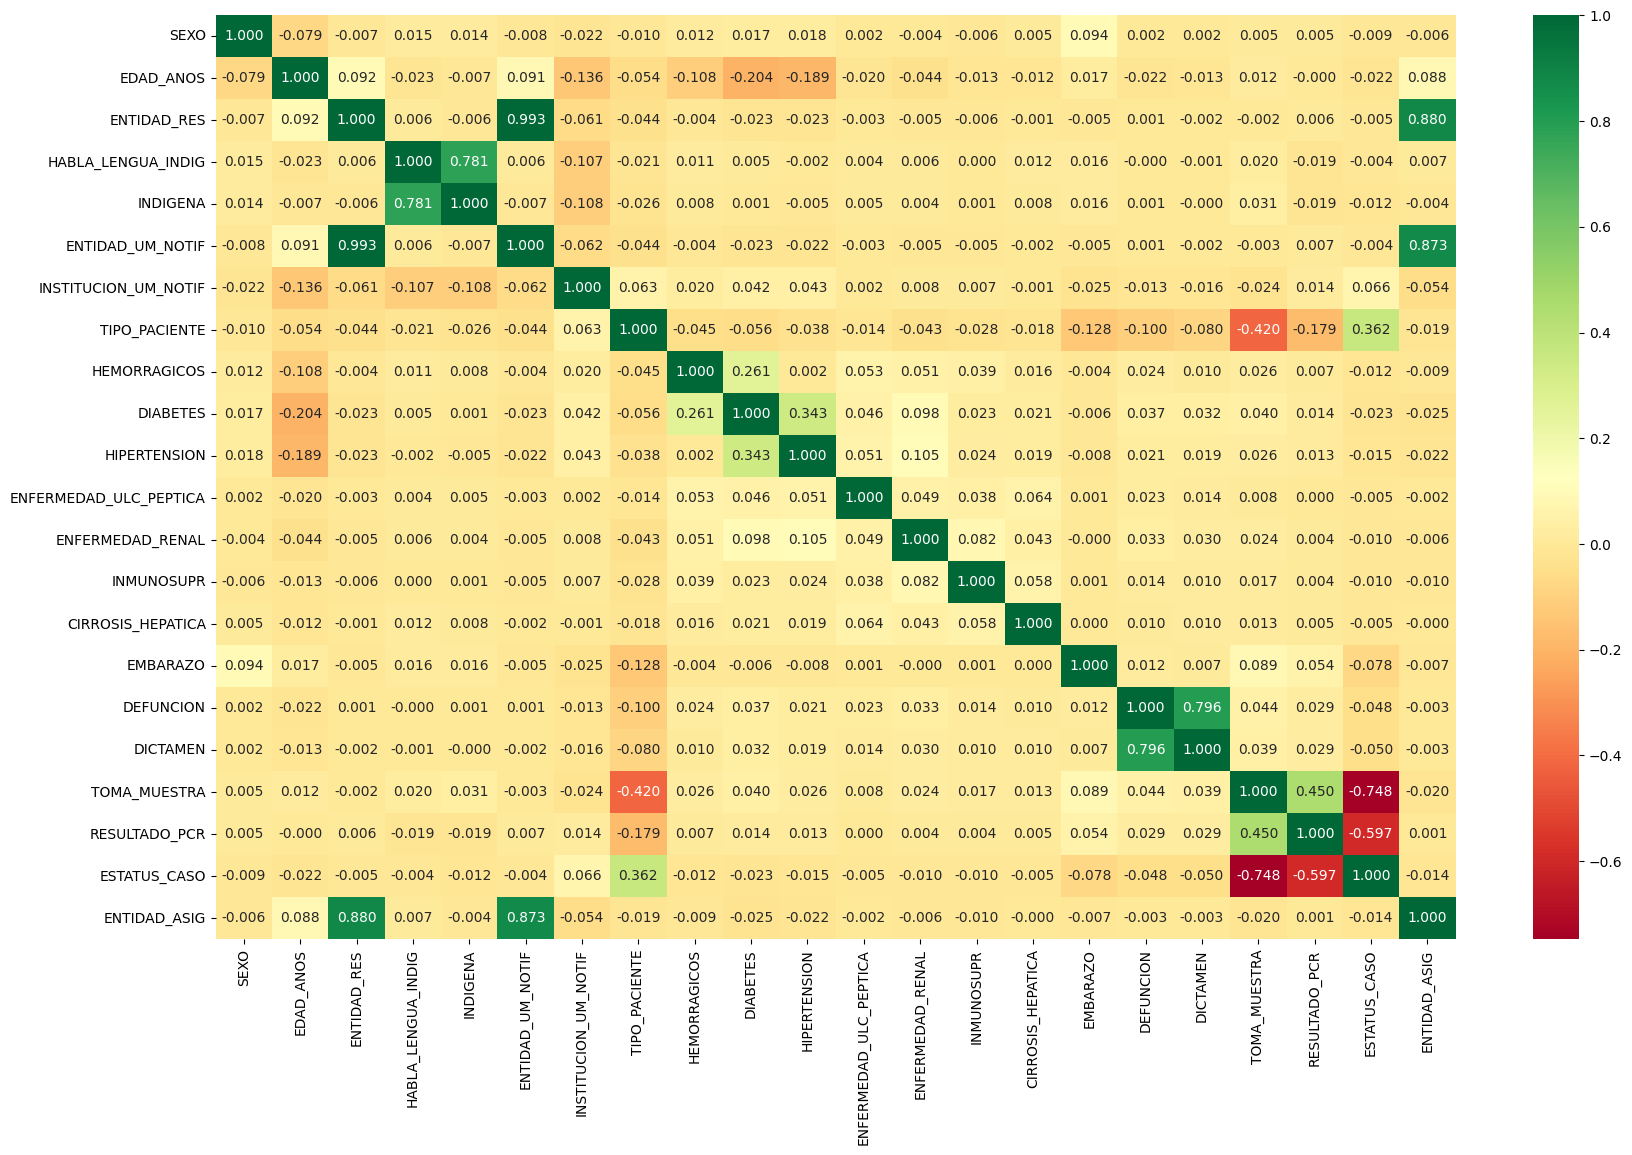

In [24]:
print("La matriz de correlación para la defunción es")
corr_matrix(dengue_data)

<div class="alert alert-block alert-info">
<b>

De esta matriz de correlación se tienen muchas correlaciones que podrían significar que podrían representarse con una sola variable. Por ejemplo, la entidad de residencia, la entidad de la unidad médica y la entidad asignada casi representan el mismo valor; pero estos no parecen tener casi impacto en nuestra variable objetivo de Defunción, por lo que podemos quedarnos solo con la variable de Entidad de Residencia. Otra de este tipo es la de ser indígena y el de hablar una lengua indígena, por lo que se dejará la variable Indígena.

También hay relaciones esperables, como lo son el resultado del PCR, la toma de la muestra y el estatus del caso. 

De entre todas las variables, parece ser que la que tiene más peso con el de Defunción es el de Dictamen, por lo que habrá que tener esta variable más en cuenta.

## Distribuciones ##

Como la única variable continua es la edad de los pacientes, esta es la variable que será estudiada para las distribuciones de probabilidad.

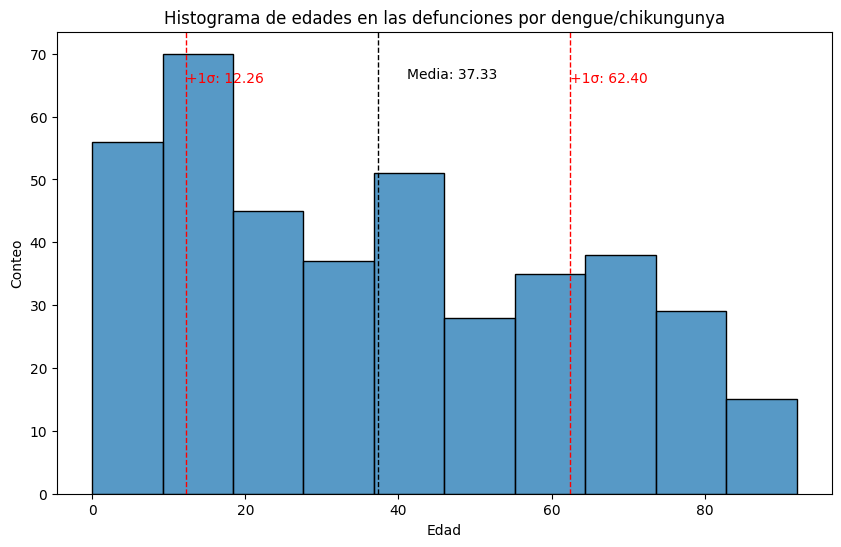

In [25]:
k = int(np.ceil(1+np.log2(len(defun_data)))) #regla de sturges con un numero entero

#Histrograma de edades en las defunciones
media = defun_data['EDAD_ANOS'].mean() #Media de las edades
desv = defun_data['EDAD_ANOS'].std()

plt.figure(figsize=(10, 6))
sns.histplot(data=defun_data, x='EDAD_ANOS', bins = k)
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.title('Histograma de edades en las defunciones por dengue/chikungunya')

#Limites del histograma en y
min_ylim, max_ylim = plt.ylim()

#Añadir la media al histograma
plt.axvline(media, color='k', linestyle='dashed', linewidth=1)
plt.text(media * 1.1, max_ylim * 0.9, f'Media: {media:.2f}')

#Añadir la desviación estándar al histograma
plt.text(media + desv, max_ylim * 0.9, f'+1σ: {media + desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.text(media - desv, max_ylim * 0.9, f'+1σ: {media - desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.axvline(media+desv, color='r', linestyle='dashed', linewidth=1)
plt.axvline(media-desv, color='r', linestyle='dashed', linewidth=1)

plt.show()

<div class="alert alert-block alert-info">
<b>

La media de edades en las defunciones es de 37.33 años y la desviación estándar es de 25.07. Esta desviación tan grande se debe a que la distribución está más cargada a la izquierda y los difuntos con mayor edad son escasos. Probablemente este desbalance sea más debido a los "pocos" datos o a que simplemente en México hay otras causas de muerte más comunes en edades avanzadas que el dengue/chikunguya.

**Ajuste de defunciones**

In [26]:
#distribuciones
distribuciones = ['cauchy', 'chi2', 'expon',  'exponpow', 'gamma',
                  'norm', 'powerlaw', 'beta', 'logistic']

Ajuste1 = defun_data['EDAD_ANOS'] 

# Atributo

fitter = Fitter(Ajuste1, distributions=distribuciones) #Ajuste a las defunciones
fitter.fit()
fitter.summary(Nbest=10, plot=False)



2024-12-12 12:30:38.430 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted expon distribution with error=0.007481)
2024-12-12 12:30:38.436 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted gamma distribution with error=0.006834)
2024-12-12 12:30:38.445 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted powerlaw distribution with error=0.019812)
2024-12-12 12:30:38.457 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted logistic distribution with error=0.008405)
2024-12-12 12:30:38.458 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=0.00819)
2024-12-12 12:30:38.464 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted beta distribution with error=0.006275)
2024-12-12 12:30:38.471 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted chi2 distribution with error=0.082755)
2024-12-12 12:30:38.493 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted exponp

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.006275,937.316183,953.321842,inf,0.073463,2.424957e-02
gamma,0.006834,960.328015,972.332259,inf,0.082995,7.201990e-03
expon,0.007481,974.411020,982.413850,inf,0.114010,4.964758e-05
norm,0.008190,956.364872,964.367702,inf,0.091849,2.042065e-03
logistic,0.008405,966.290325,974.293155,inf,0.084666,5.733476e-03
cauchy,0.009217,1019.592476,1027.595305,inf,0.163809,6.100457e-10
powerlaw,0.019812,1289.756978,1301.761223,inf,0.794958,4.196438e-274
exponpow,0.035745,1370.454654,1382.458898,inf,0.796661,1.077856e-275
chi2,0.082755,1662.728277,1674.732521,inf,0.793036,2.535946e-272


Tenemos que la distribucion que mejor se ajusta a los datos de las defunciones es la distribución beta, que se ve de la siguiente forma

<div> <img src="Beta_distribution_pdf.png" alt="Drawing" style="width: 600px;"/></div>

y se escribe como

$$f(x,\alpha,\beta)=\dfrac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)},$$
donde $B(\alpha,\beta)$ es la función Beta dada por

$$B(\alpha,\beta)=\dfrac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)},$$
y donde $\Gamma(\alpha)$ es la función Gamma.

Así, el ajuste se ve de la siguiente forma

2024-12-12 12:30:38.947 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted beta distribution with error=0.006275)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.006275,937.316183,953.321842,inf,0.073463,0.02425


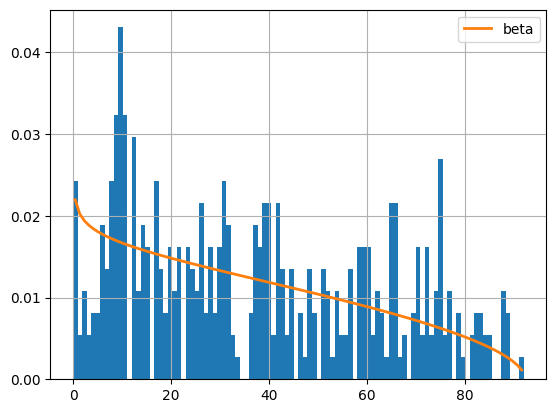

In [27]:
f = Fitter(Ajuste1, distributions=['beta'])
f.fit()
f.summary()

In [28]:
parametro = f.fitted_param['beta']
print("Los valores de los parámetros son", parametro)

Los valores de los parámetros son (0.9300358059751028, 1.5400073632295683, -3.218778676393623e-22, 92.30169864276118)


<div class="alert alert-block alert-info">
<b>

El mejor ajuste para la edad de las defunciones es la distribución beta con parámetros $\alpha=0.93$  y  $\beta=1.54$.

**Ajuste de recuperaciones**

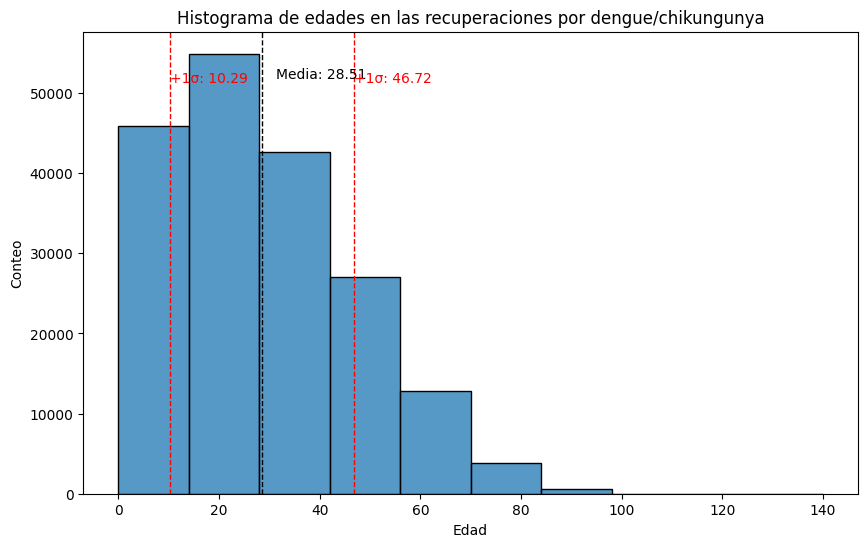

In [29]:
#Histrograma de edades en las defunciones
media = recup_data['EDAD_ANOS'].mean() #Media de las edades
desv = recup_data['EDAD_ANOS'].std()   #Desviación estándar de las edades

plt.figure(figsize=(10, 6))
sns.histplot(data=recup_data, x='EDAD_ANOS', bins = k)
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.title('Histograma de edades en las recuperaciones por dengue/chikungunya')

#Limites del histograma en y
min_ylim, max_ylim = plt.ylim()

#Añadir la media al histograma
plt.axvline(media, color='k', linestyle='dashed', linewidth=1)
plt.text(media * 1.1, max_ylim * 0.9, f'Media: {media:.2f}')

#Añadir la desviación estándar al histograma
plt.text(media + desv, max_ylim * 0.9, f'+1σ: {media + desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.text(media - desv, max_ylim * 0.9, f'+1σ: {media - desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.axvline(media+desv, color='r', linestyle='dashed', linewidth=1)
plt.axvline(media-desv, color='r', linestyle='dashed', linewidth=1)

plt.show()

<div class="alert alert-block alert-info">
<b>

La media de edades en las recuperaciones es de 28.51 años y la desviación estándar es de 18.21. Esta distribución se encuentra todavía más fuertemente cargada a la izquierda, por lo que la desviación estándar es menor.

In [30]:
#distribuciones
distribuciones = ['cauchy', 'chi2', 'expon',  'exponpow', 'gamma',
                  'norm', 'powerlaw', 'beta', 'logistic']


Ajuste2 = recup_data['EDAD_ANOS']


# Atributo

fitter = Fitter(Ajuste2, distributions=distribuciones)
fitter.fit()
fitter.summary(Nbest=10, plot=False)



2024-12-12 12:30:39.693 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=0.002363)
2024-12-12 12:30:39.740 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted logistic distribution with error=0.002392)
2024-12-12 12:30:39.840 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted cauchy distribution with error=0.003095)
2024-12-12 12:30:39.877 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted expon distribution with error=0.003901)
2024-12-12 12:30:40.203 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted gamma distribution with error=0.001651)
2024-12-12 12:30:40.437 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted chi2 distribution with error=0.001651)
2024-12-12 12:30:40.636 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted powerlaw distribution with error=0.013899)
2024-12-12 12:30:40.970 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted bet

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.001561,1586.206332,1626.777926,inf,0.022282,2.066812e-81
chi2,0.001651,1293.692151,1324.120846,inf,0.034401,1.758930e-193
gamma,0.001651,1293.692123,1324.120819,inf,0.034401,1.736124e-193
norm,0.002363,1779.048928,1799.334725,inf,0.074946,0.000000e+00
logistic,0.002392,1437.973348,1458.259145,inf,0.070331,0.000000e+00
cauchy,0.003095,1232.074628,1252.360425,inf,0.139560,0.000000e+00
expon,0.003901,1165.150560,1185.436357,inf,0.151972,0.000000e+00
powerlaw,0.013899,1261.202235,1291.630931,inf,0.644086,0.000000e+00
exponpow,0.017657,1496.487358,1526.916054,inf,0.790770,0.000000e+00


El mejor ajuste también es la distribución beta, y se ve de la forma

2024-12-12 12:30:43.668 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted beta distribution with error=0.001561)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.001561,1586.206332,1626.777926,inf,0.022282,2.066812e-81


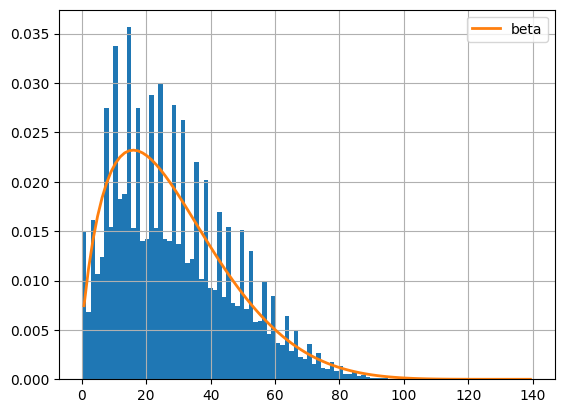

In [31]:
f = Fitter(Ajuste2, distributions=['beta'])
f.fit()
f.summary()

In [32]:
parametro = f.fitted_param['beta']
print("Los valores de los parámetros son", parametro)

Los valores de los parámetros son (1.7989341015492648, 6.8307185307890546, -1.063280140706384, 141.33274992958513)


<div class="alert alert-block alert-info">
<b>

El mejor ajuste para la edad de las defunciones es la distribución beta con parámetros $\alpha=1.80$  y  $\beta=6.83$.

## Regresión lineal ##

En este apartado se estudian los datos utilizando la regresión lineal como modelo supervisado de aprendizaje automatizado (Machine Learning o ML), de tal suerte que se pueda obtener la variable objetivo: la defunción del paciente.

In [61]:
#Modelo de regresión lineal con ML supervisado
def linear_regression_model(data,target_column):
   
    features = data.drop(columns=[target_column])
    target = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)**0.5

    print(f'Model Coefficients: {model.coef_}')
    print(f'Model Intercept: {model.intercept_}')
    print('Mean Squared Error: ', mse)
    print('Root Mean Squared Error: ', rmse)
    print('Mean Absolute Error: ', mae)
    print('R2 Score: ', r2)


    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actuales')
    plt.ylabel('Predicho')
    plt.title('Valores Actuales vs Predichos')
    plt.text(0.1, 0.95, f'RMSE: {rmse:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.1, 0.85, f'R2 Score: {r2:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    #plt.text(0.05, 0.90, f'Coefficients: {model.coef_}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.show()


Model Coefficients: [-6.76223366e-06 -3.05674085e-05 -1.17712321e-04 -1.53562222e-04
  2.56105051e-04  2.12151711e-04  4.57971545e-07 -4.69504595e-03
  1.03805947e-02  1.12319030e-03 -7.59198796e-04  1.42221186e-02
  5.97646593e-03  9.55946909e-03 -7.42374851e-05  2.09494390e-03
  3.23835694e-01  1.43654410e-04  1.37874436e-04  8.87523052e-04
 -7.69219381e-05]
Model Intercept: 0.29895553221833326
Mean Squared Error:  0.0007666479320558303
Root Mean Squared Error:  0.027688407900343968
Mean Absolute Error:  0.048960453001403274
R2 Score:  0.607241428821214


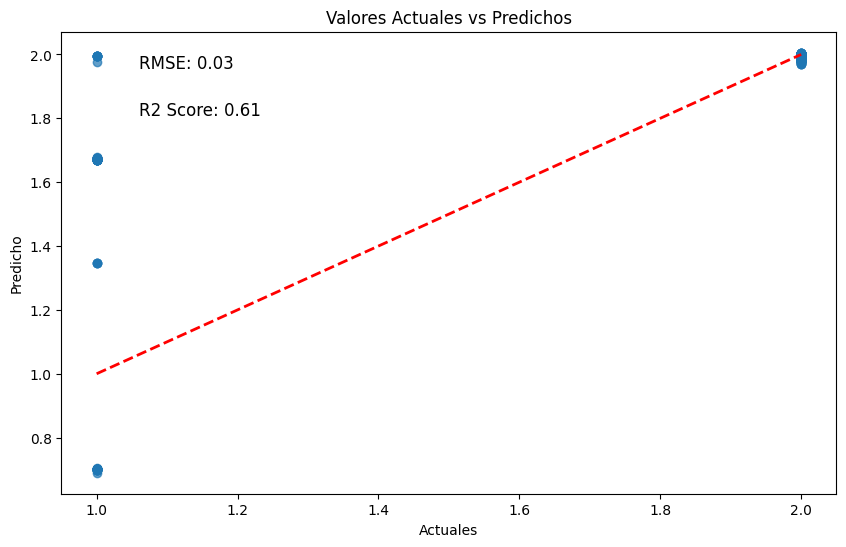

In [62]:
linear_regression_model(dengue_data,'DEFUNCION')

<div class="alert alert-block alert-info">
<b>

Como la defunción del paciente es una variable categórica (1 si falleció y 2 si no falleció), tenemos que la gráfica de la regresión linea parece no decirnos mucho. De hecho nos podría hacer pensar que no se sigue correctamente la linealidad. A pesar de esto, contamos con un RMSE bajo y con un $R^{2}$ Score, si bien mejorable, bastante decente para tratarse justamente de varibles categóricas.